# Case 1 -- Preliminary Analysis: Half-Maximum and Pearson Correlation (Poplar Side Branch)

**Dissertation Chapter 6, Section 6.1, "Influence of Dispersion and Cross-Sectional Area on Transport Analysis" (p. 102):**

> In this case study, five time-activity curves (TACs) retrieved from consecutive regions of
> interest (ROIs) along a 5.7 cm long side branch of a poplar tree were investigated (Figure
> fig:storage_change_hmax a). An initial evaluation using the half-maximum method showed that
> the resulting distance-time relationship was curved rather than linear (Figure
> fig:storage_change_hmax b).

- Data: `Poplar_02_L1_M3_second_Branch.txt` (raw ROI export, 5 ROIs along the side branch).
- Reproduces: Figure `fig:storage_change_hmax` (half-maximum analysis,
  `Figures/exchange_change_hmax_a.pdf` / `_b.pdf`) and Figure `fig:poplar_exchange_combined`
  (Pearson correlation heatmap + aligned curves, `Figures/poplar_exchange_pearson.pdf` /
  `poplar_exchange_aligned.pdf`).
- Companion notebooks (main MCT fits): `case1_changing_dispersion_poplar_side_branch.ipynb`
  (Changing Dispersion Case), `case1_changing_area_poplar_side_branch.ipynb` (Changing Cross-Sectional-Areas Case),
  `case1_appendix_m02_vs_m13_test_poplar_side_branch.ipynb` (Appendix M02-vs-M13 test).

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate

import sys; sys.path.insert(0, "..")
from utils import *

In [2]:
import os
os.makedirs("output/figures", exist_ok=True)


## Load ROI data

In [3]:
df = pd.read_csv("data/case1_poplar_side_branch_preliminary.csv", index_col=0)
df = df.iloc[1:]


In [4]:
xi=list(df.columns)
xi = xi [0:5]
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

## Pearson correlation and curve alignment (`fig:poplar_exchange_combined`)

Aligns the 5 ROI curves (optimizing a time shift and amplitude scale per curve against ROI1 as reference) before computing pairwise Pearson correlations.

shift=-3.11, scale=1.09, loss=2385464372.1971
shift=-4.81, scale=4.45, loss=12122756748.0275
shift=-8.52, scale=1.37, loss=6217261419.5972
shift=-2.17, scale=1.79, loss=623658591.2462
shift=-1.84, scale=4.18, loss=13761621881.0793
shift=-0.48, scale=2.94, loss=4302202333.0599
shift=5.46, scale=1.52, loss=1057571032.9995
shift=-4.43, scale=3.06, loss=3622921049.1219
shift=-6.05, scale=3.79, loss=6760521264.7459
shift=-5.73, scale=2.26, loss=2224915583.4000
shift=4.92, scale=4.28, loss=33223243386.5841
shift=2.76, scale=3.88, loss=17841895432.3941
shift=2.04, scale=2.71, loss=4010936007.8171
shift=-3.94, scale=0.21, loss=7366915350.7864
shift=4.47, scale=0.37, loss=2564698126.4647
shift=-7.97, scale=2.40, loss=3807538310.3341
shift=-1.18, scale=2.84, loss=3430577238.7776
shift=-9.89, scale=3.49, loss=5978674249.0754
shift=3.76, scale=2.09, loss=2089554147.7779
shift=8.81, scale=4.52, loss=67985770201.3791
shift=0.69, scale=1.61, loss=40262903.5950
shift=6.26, scale=3.30, loss=19920127449

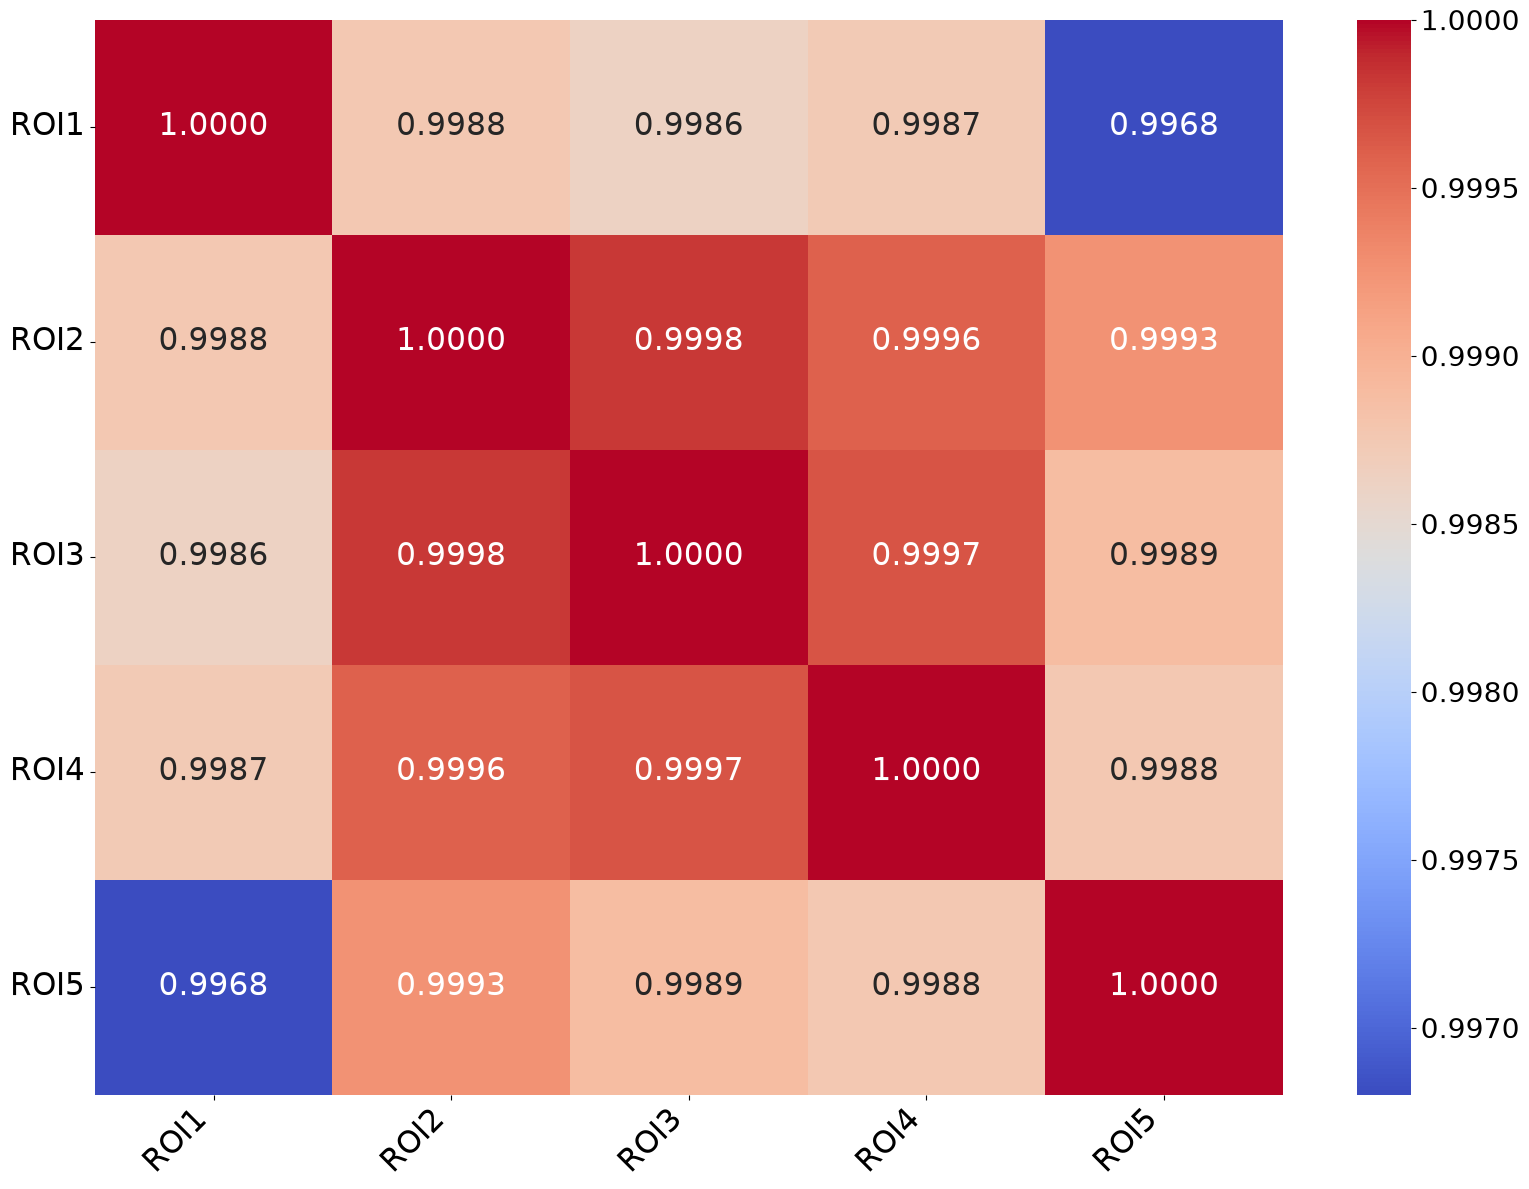

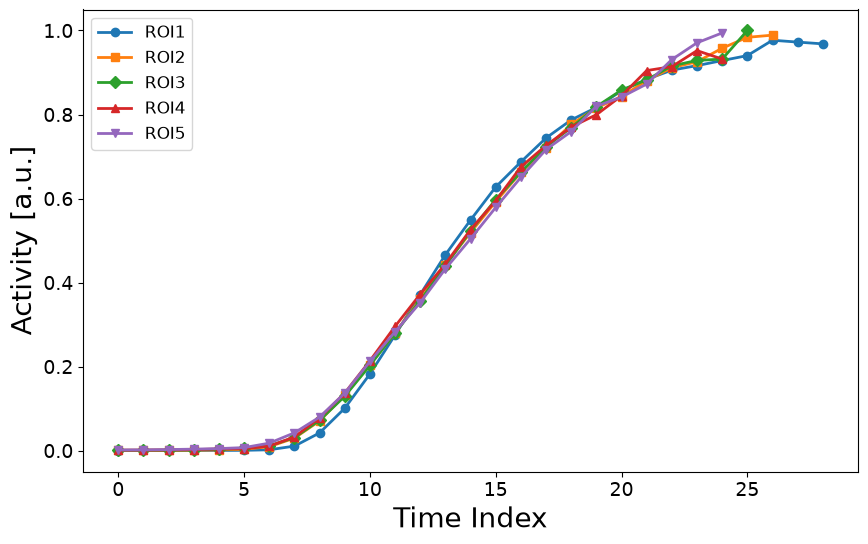

In [5]:
data = df

# ====================
# IMPORTS
# ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d
from scipy.optimize import minimize, differential_evolution
from scipy.stats import pearsonr

# ====================
# FUNCTION DEFINITIONS
# ====================

def shift_curve_interp(curve, shift, target_len):
    """
    Shift curve by a (possibly fractional) amount using interpolation.
    Fills out-of-bounds values with NaN.
    """
    x = np.arange(len(curve))
    interpolator = interp1d(x, curve, kind='linear', bounds_error=False, fill_value=np.nan)
    x_shifted = np.arange(target_len) + shift
    return interpolator(x_shifted)

def optimize_shift_and_scale(curve, reference, search_bounds=(-10, 10), scale_bounds=(0.1, 5.0), method='mse'):
    """
    Find optimal (time shift, amplitude scale) to align curve to reference.
    """

    def loss_fn(params):
        shift, scale = params
        shifted = shift_curve_interp(curve, shift, len(reference)) * scale

        valid = ~np.isnan(shifted) & ~np.isnan(reference)
        if np.sum(valid) < 2:
            print(f"Too few valid points for shift={shift:.2f}, scale={scale:.2f}")
            return np.inf

        residuals = (shifted - reference) ** 2
        weights = np.ones(len(reference))
        weights[:len(reference) // 2] *= 2.0
        weights = weights[valid]
        residuals = residuals[valid]

        weights /= np.sum(weights)
        loss = np.sum(weights * residuals)

        print(f"shift={shift:.2f}, scale={scale:.2f}, loss={loss:.4f}")
        return loss

    bounds = [search_bounds, scale_bounds]
    result = differential_evolution(loss_fn, bounds)
    return result.x  # (best_shift, best_scale)

# ====================
# DATA SELECTION
# ====================
# Replace xi[1:4] with your actual indices or column names
selected_cols = xi[0:9]
custom_names = [f"ROI{i+1}" for i in range(len(selected_cols))]

# ====================
# ALIGNMENT
# ====================
aligned_curves = {}
shifts = {}

# Use unscaled reference (first curve)
ref_curve = data[selected_cols[0]].to_numpy(dtype=float)
aligned_curves[custom_names[0]] = ref_curve
shifts[custom_names[0]] = (0.0, 1.0)

for name, col in zip(custom_names[1:], selected_cols[1:]):
    curve = data[col].to_numpy(dtype=float)

    opt_shift, opt_scale = optimize_shift_and_scale(curve, ref_curve)
    aligned = shift_curve_interp(curve, opt_shift, len(ref_curve)) * opt_scale

    aligned_curves[name] = aligned
    shifts[name] = (opt_shift, opt_scale)

aligned_data = pd.DataFrame(aligned_curves)
aligned_data = aligned_data / aligned_data.max().max()

# ====================
# PLOTS
# ====================

print("Optimal shifts (time, scale):")
for name, (shift, scale) in shifts.items():
    print(f"{name}: Δt = {shift:.2f}, scale = {scale:.3f}")
plt.figure(figsize=(16, 12))

# Compute correlation separately to reformat colorbar later
corr_matrix = aligned_data.corr(method="pearson", min_periods=4)

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    annot_kws={"size": 22},
    cbar_kws={"format": "%.4f"}  # Format colorbar to 4 decimal places
)

# Increase font size of tick labels
plt.xticks(fontsize=22, rotation=45, ha="right")
plt.yticks(fontsize=22, rotation=0)

# Resize colorbar label font and ticks
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=20)

plt.title("", fontsize=20)
plt.tight_layout()

plt.savefig("output/figures/poplar_exchange_pearson.pdf", format="pdf")  
plt.show()

markers = ['o', 's', 'D', '^', 'v', '>', '<', 'p', '*', 'h']  # Extend as needed
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(10, 6))
for i, col in enumerate(aligned_data.columns):
    plt.plot(
        aligned_data[col],
        label=col,
        linewidth=2,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        markevery=1,  # place marker every 10 points (adjust as needed)
        markersize=6
    )

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Time Index", fontsize=20)
plt.ylabel("Activity [a.u.]", fontsize=20)

plt.legend(fontsize=12)
plt.title("", fontsize=16)
#plt.ylim(0, 1)
plt.savefig("output/figures/poplar_exchange_aligned.pdf", format="pdf")  
plt.show()

## Half-maximum analysis (`fig:storage_change_hmax`)

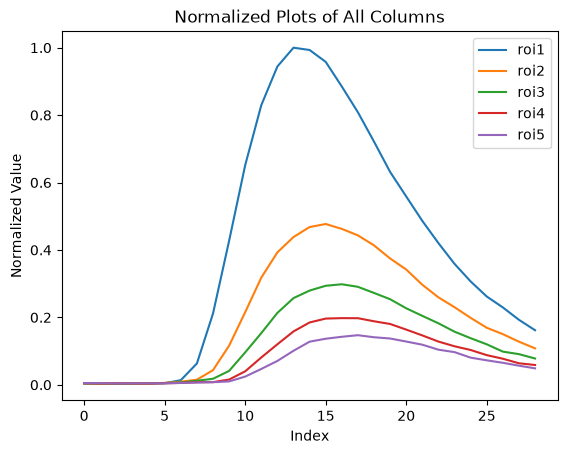

In [7]:
rois = plot_all_columns(data_unc[:,0:9])

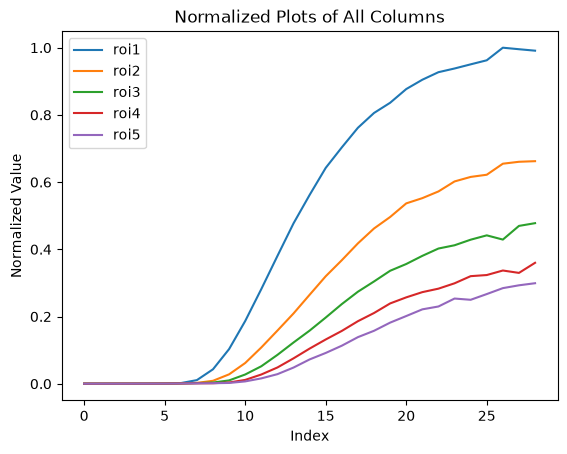

In [8]:
rois = plot_all_columns(data_cor[:,0:9])

In [9]:
xi=xi[0:9]

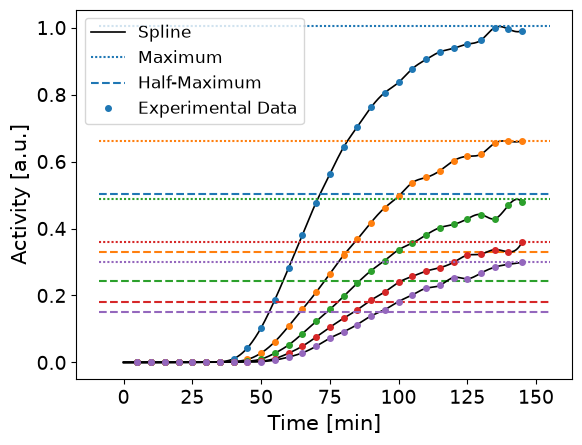

In [10]:
results = process_and_plot_rois(
    rois, t, savefig_name="output/figures/exchange_change_hmax_a.pdf"
)


In [11]:
print("Amplitude ratios between consecutive ROIs:", results["ratios"])


Amplitude ratios between consecutive ROIs: [np.float64(1.514818844553241), np.float64(1.359188522910205), np.float64(1.353770754811352), np.float64(1.2032576606250869)]


In [12]:
hmaxi = np.array(list(compute_hmax_times(results, np.linspace(0, 145, 500)).values()))


[   2.62659026 -192.35571585] 0.3745038274804596


np.float64(0.9425171394582815)

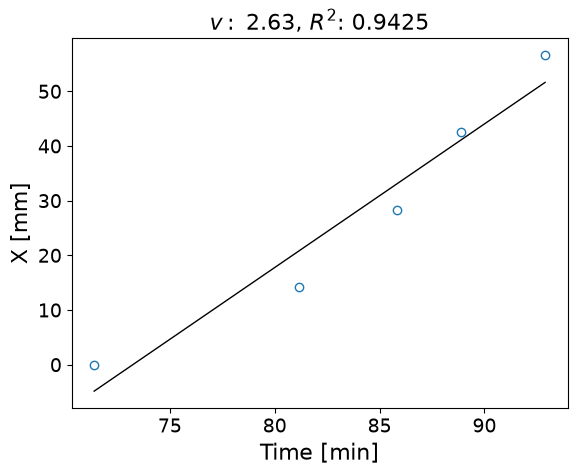

In [13]:
points=np.array(xi, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))

mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))

plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 

for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')
plt.xlabel("Time [min]",fontsize=16)
plt.ylabel("X [mm]",fontsize=16)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2

plt.savefig("output/figures/exchange_change_hmax_b.pdf", format="pdf")  

fit, V=np.polyfit(hmaxi,points,1, cov=True)
print(fit,np.sqrt(V[0][0]))

np.corrcoef(hmaxi, points)[0,1]**2

In [14]:
print(f"Relative velocity uncertainty: {np.sqrt(V[0][0]) / np.around(mbinter_v[0][0], 2) * 100:.2f}%")


Relative velocity uncertainty: 14.24%
